# Transformaciones a Tiempo-Frecuencia


In [4]:
# Cargar los datos acondicionados
from os import path
import pandas as pd

FILE_PATH = './data/eeg_eye_state_clean.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe.")
    raise FileNotFoundError(f"El archivo no existe: {FILE_PATH}")
else:
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state_clean.csv


In [5]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,0.736484,-0.009636,1.178945,1.235709,0.510713,-1.831197,1.153277,1.375999,1.166158,0.367772,0.372550,0.070037,0.896983,0.846142,0,0.000000
1,0.630255,-0.164882,1.365325,1.327963,-0.033855,-1.815302,1.168870,1.147867,0.407848,-0.319549,0.214932,0.017004,0.770335,0.618404,0,0.007812
2,0.674703,-0.096572,1.501320,1.568564,-0.199946,-1.967427,1.170797,0.911751,0.530619,-0.380182,0.201532,0.153103,0.725777,0.695611,0,0.015625
3,0.739805,0.086415,1.510323,1.595198,0.083062,-2.007020,1.156651,0.795702,0.812917,0.222368,0.335384,0.417372,0.767920,0.928266,0,0.023438
4,0.649864,0.063729,1.296289,1.437884,0.349025,-1.824252,1.117905,0.560304,0.453218,0.559581,0.444195,0.471846,0.788656,0.970052,0,0.031250


## Transformada de fourier de corto plazo


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

In [7]:
def apply_stft(series, fs = FS, window_sec = 2, overlap_pct = 0.75):
    n_per_seg = int(window_sec * fs)
    n_overlap = int(n_per_seg * overlap_pct)

    f, t, Zxx = stft(series, fs=fs, window='hann', nperseg=n_per_seg, noverlap=n_overlap)
    psd = np.abs(Zxx)
    
    return f, t, psd

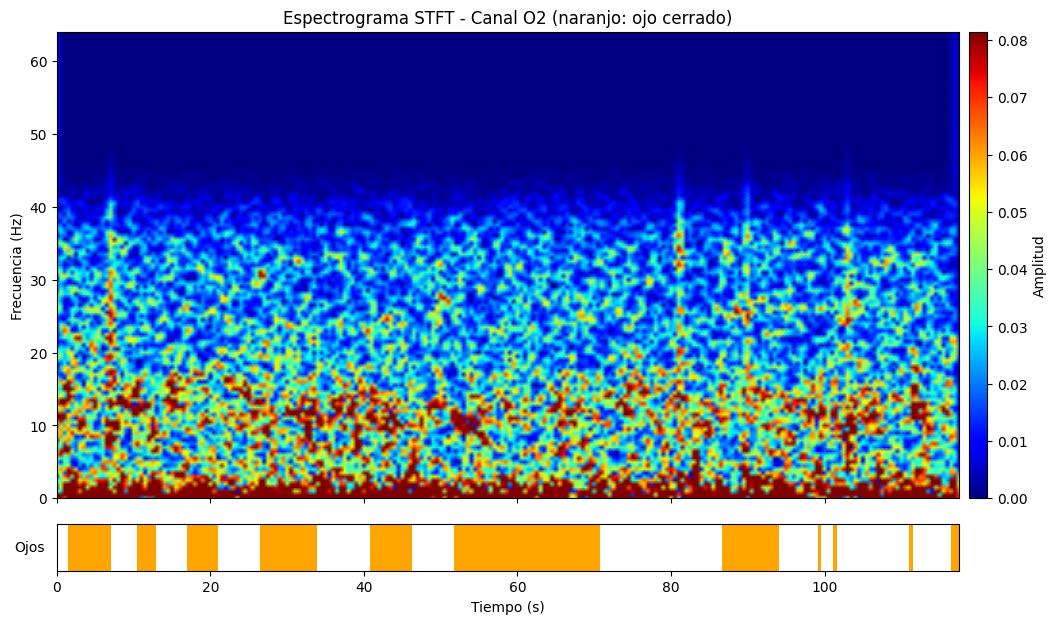

In [8]:
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

target = 'O2'
f, t, psd = apply_stft(df[target])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, 
                             gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)

im = ax1.pcolormesh(t, f, psd, shading='gouraud', cmap='jet', 
                    vmin=0, vmax=np.percentile(psd, 95))
ax1.set_title(f'Espectrograma STFT - Canal {target} (naranjo: ojo cerrado)')
ax1.set_ylabel('Frecuencia (Hz)')

divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im, cax=cax, label='Amplitud')

states_at_t = [df.iloc[(df['time_sec'] - ti).abs().idxmin()][TARGET_COL] for ti in t]
states_matrix = np.array(states_at_t).reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])

ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye, 
           extent=[t.min(), t.max(), 0, 1], interpolation='nearest')

ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')

ax1.set_xlim(t.min(), t.max())
ax2.set_xlim(t.min(), t.max())

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
cax2.axis('off')

plt.show()

## Transformada de Wavelet


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pywt

In [12]:
def apply_cwt(series, fs=FS, freq_min=4, freq_max=40, n_freqs=80, wavelet='cmor1.5-1.0'):
    """
    Aplica la Transformada Wavelet Continua (CWT) a una señal EEG.

    Parámetros
    ----------
    series    : array-like  - Señal de entrada (1D).
    fs        : int         - Frecuencia de muestreo en Hz.
    freq_min  : float       - Frecuencia mínima de análisis en Hz.
    freq_max  : float       - Frecuencia máxima de análisis en Hz.
    n_freqs   : int         - Número de escalas (resolución frecuencial).
    wavelet   : str         - Wavelet madre. Se usa Morlet compleja (cmor) por
                              su localización conjunta tiempo-frecuencia.

    Retorna
    -------
    freqs     : ndarray     - Frecuencias correspondientes a cada escala (Hz).
    t         : ndarray     - Vector de tiempo (s).
    power     : ndarray     - Densidad de potencia espectral |CWT|² (freqs × tiempo).
    """
    # Calcular escalas a partir del rango de frecuencias deseado
    # pywt.scale2frequency convierte escala → frecuencia: f = f_c / (escala * dt)
    dt = 1.0 / fs
    central_freq = pywt.central_frequency(wavelet)
    scales = central_freq / (np.linspace(freq_min, freq_max, n_freqs) * dt)
    scales = scales[::-1]  # ordenar de menor a mayor escala (mayor a menor frecuencia)

    signal = np.array(series, dtype=np.float64)
    coeffs, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=dt)

    # Densidad de potencia: módulo al cuadrado de los coeficientes complejos
    power = np.abs(coeffs) ** 2
    t = np.arange(len(signal)) * dt

    return freqs, t, power

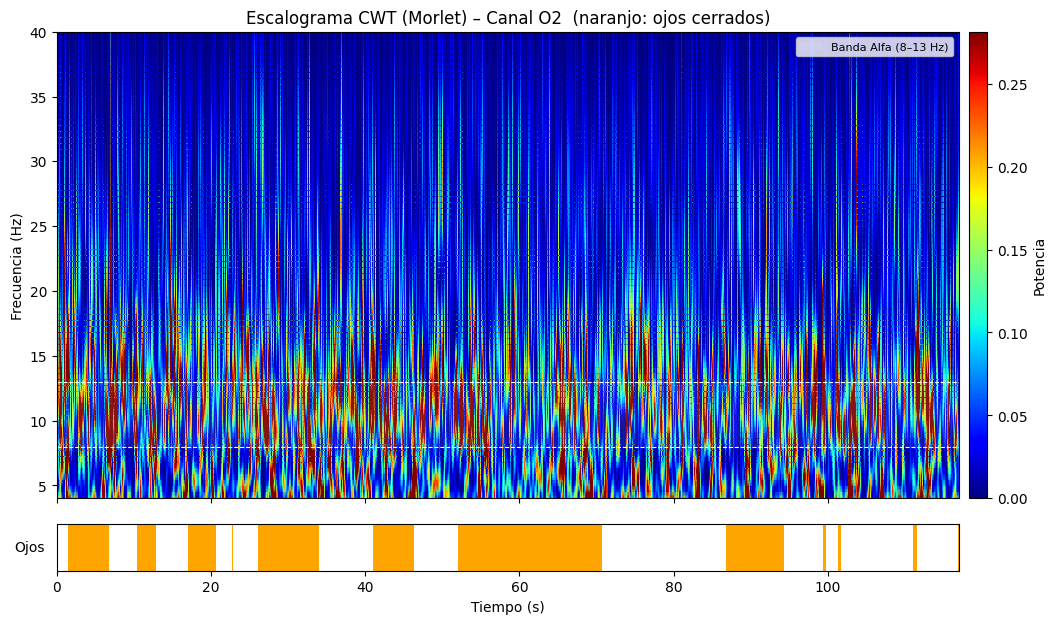

In [13]:
target = 'O2'
freqs, t_cwt, power = apply_cwt(df[target], fs=FS)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)

im = ax1.pcolormesh(t_cwt, freqs, power, shading='gouraud', cmap='jet',
                    vmin=0, vmax=np.percentile(power, 95))

# Resaltar banda alfa (8-13 Hz)
ax1.axhspan(8, 13, color='white', alpha=0.08, lw=0, label='Banda Alfa (8–13 Hz)')
ax1.axhline(8,  color='white', linestyle='--', linewidth=0.8)
ax1.axhline(13, color='white', linestyle='--', linewidth=0.8)

ax1.set_title(f'Escalograma CWT (Morlet) – Canal {target}  (naranjo: ojos cerrados)')
ax1.set_ylabel('Frecuencia (Hz)')
ax1.legend(loc='upper right', fontsize=8)

divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia')

# Barra de estado ocular
states_at_t = [df.iloc[(df['time_sec'] - ti).abs().idxmin()][TARGET_COL] for ti in t_cwt]
states_matrix = np.array(states_at_t).reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])

ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[t_cwt.min(), t_cwt.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')

ax1.set_xlim(t_cwt.min(), t_cwt.max())
ax2.set_xlim(t_cwt.min(), t_cwt.max())

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
cax2.axis('off')

plt.show()